In [2]:
import numpy as np
import pandas as pd
import h5py

from SushiLife import *

In [4]:
f = h5py.File("../data/stock_info.hdf5", "r")
array_stock, axis_stock = load_data(f, "stock", chunks=5, in_memory=False)
array_value, axis_value = load_data(f, "value", chunks=5, in_memory=False)

data_stock = DataAsset(array_stock, axis_stock, chunks=5)
data_value = DataAsset(array_value, axis_value, chunks=5)

# with pandas dataframe

In [27]:
%%time
updater = Updater(pd.Timestamp(2002, 6, 15), data_stock.dates)

# 거래소 생성
exchange_stock = Exchange()
exchange_stock.set_DataAsset(data_stock)

# 주식 계좌 생성
stock_account = StockAccount(exchange_stock, 출력=False)

# 거래 에이전트 생성 및 주식 계좌 등록
agent = Agent(1e8, 출력=True)
agent.set_account("stock", stock_account)

# 날짜가 변할시 업데이트 요청
updater.set_data(data_stock)
updater.set_data(data_value)

updater.set_exchange(exchange_stock)

updater.set_agent(agent)

updater.initialization()

# 백테스트
columns = ["상장시가총액(원)", "지배주주순이익(원)(직전4분기)", "지배주주지분(원)",
   "현금흐름(원)(직전4분기)", "매출액(원)(직전4분기)"]


while updater._date != updater._list_date[-1]:
    fin_stat = data_value.get_info(updater._date, num=2,
                                 fields=columns)
    
    df = pd.DataFrame(fin_stat[-2], index=data_value.codes, columns=columns)
    df = df[~np.isnan(df["상장시가총액(원)"])] # 상장종목 고려 
    df = df.sort_values(by=['상장시가총액(원)']).iloc[:int(len(df.index) * 0.3)] # 소형주

    # 종목선정
    df["PER"] = df["상장시가총액(원)"] / df["지배주주순이익(원)(직전4분기)"]
    df["PBR"] = df["상장시가총액(원)"] / df["지배주주지분(원)"]
    df["PCR"] = df["상장시가총액(원)"] / df["현금흐름(원)(직전4분기)"]
    df["PSR"] = df["상장시가총액(원)"] / df["매출액(원)(직전4분기)"]

    df = df[df["PER"] > 0]
    df = df[df["PBR"] > 0]
    df = df[df["PCR"] > 0]
    df = df[df["PSR"] > 0]

    df["Rank"] = (df["PER"].rank() + df["PBR"].rank() + df["PCR"].rank() + df["PSR"].rank()).rank()

    df = df[df["Rank"] < 51]

    # 매도
    매도종목 = agent.accounts["stock"].keys()
    매수종목 = df.index
    현재가 = data_stock.get_info(updater._date, codes=매도종목, fields=["현재가"]).reshape(-1)
    
    i = 0
    for 종목코드 in 매도종목:
        매도수량 = agent.accounts["stock"][종목코드]["보유수량"]
        agent.sell("stock", 종목코드, 현재가[i], 매도수량)
        i += 1

    # 매수
    현재가 = data_stock.get_info(updater._date, codes=매수종목, fields=["현재가"]).reshape(-1)
    i = 0
    for 종목코드 in 매수종목:
        매수수량 = (agent.cash / 50 / 현재가[i])
        agent.buy("stock", 종목코드, 현재가[i], 매수수량)
        i += 1
    
    for i in range(20):
        if updater._date == updater._list_date[-1]:
            break
        updater.update()

장마감 :  2002-06-17 00:00:00 

 당일수익률(%) :  0.1693210667318404 
 누적수익률(%) :  0.16932106673184233 
 CAGR(%) 85.42851590854626 
 MDD :  0.0 
 총자산(원) :  100169321.06673184 
 --------------------------------------------------

장마감 :  2002-06-18 00:00:00 

 당일수익률(%) :  -3.718313339914199 
 누적수익률(%) :  -3.55528816099393 
 CAGR(%) -99.86485137905676 
 MDD :  -3.7183133399141974 
 총자산(원) :  96444711.83900607 
 --------------------------------------------------

장마감 :  2002-06-19 00:00:00 

 당일수익률(%) :  -0.011145682832861492 
 누적수익률(%) :  -3.566037582684578 
 CAGR(%) -98.79408101594983 
 MDD :  -3.7290445913354655 
 총자산(원) :  96433962.41731542 
 --------------------------------------------------

장마감 :  2002-06-20 00:00:00 

 당일수익률(%) :  0.3043873964848721 
 누적수익률(%) :  -3.2725047551553144 
 CAGR(%) -95.19788897883772 
 MDD :  -3.7290445913354655 
 총자산(원) :  96727495.24484469 
 --------------------------------------------------

장마감 :  2002-06-21 00:00:00 

 당일수익률(%) :  -0.9451019620812797 
 누적수익

장마감 :  2002-08-14 00:00:00 

 당일수익률(%) :  1.4127798049719515 
 누적수익률(%) :  -2.774465928194836 
 CAGR(%) -15.975916785788591 
 MDD :  -10.261831400969585 
 총자산(원) :  97225534.07180516 
 --------------------------------------------------

장마감 :  2002-08-16 00:00:00 

 당일수익률(%) :  0.7428960628572923 
 누적수익률(%) :  -2.0521812634834213 
 CAGR(%) -11.668370970048436 
 MDD :  -10.261831400969585 
 총자산(원) :  97947818.73651658 
 --------------------------------------------------

장마감 :  2002-08-19 00:00:00 

 당일수익률(%) :  1.4921574932306476 
 누적수익률(%) :  -0.5906455467505123 
 CAGR(%) -3.322078343551549 
 MDD :  -10.261831400969585 
 총자산(원) :  99409354.45324948 
 --------------------------------------------------

장마감 :  2002-08-20 00:00:00 

 당일수익률(%) :  1.1343798868352628 
 누적수익률(%) :  0.5370341757999109 
 CAGR(%) 3.0532694613467637 
 MDD :  -10.261831400969585 
 총자산(원) :  100537034.17579992 
 --------------------------------------------------

장마감 :  2002-08-21 00:00:00 

 당일수익률(%) :  1.0478022

장마감 :  2002-10-14 00:00:00 

 당일수익률(%) :  1.3548007303295178 
 누적수익률(%) :  -0.32580973215016185 
 CAGR(%) -0.9877122747187883 
 MDD :  -10.261831400969585 
 총자산(원) :  99674190.26784983 
 --------------------------------------------------

장마감 :  2002-10-15 00:00:00 

 당일수익률(%) :  -0.2722106058307022 
 누적수익률(%) :  -0.5971334493351299 
 CAGR(%) -1.7904473846966362 
 MDD :  -10.261831400969585 
 총자산(원) :  99402866.55066487 
 --------------------------------------------------

장마감 :  2002-10-16 00:00:00 

 당일수익률(%) :  0.6794566933322296 
 누적수익률(%) :  0.07826598080746816 
 CAGR(%) 0.23433897894362676 
 MDD :  -10.261831400969585 
 총자산(원) :  100078265.98080747 
 --------------------------------------------------

장마감 :  2002-10-17 00:00:00 

 당일수익률(%) :  1.7814059213811209 
 누적수익률(%) :  1.8610661370051185 
 CAGR(%) 5.62439210488066 
 MDD :  -10.261831400969585 
 총자산(원) :  101861066.13700512 
 --------------------------------------------------

장마감 :  2002-10-18 00:00:00 

 당일수익률(%) :  -1.496

장마감 :  2002-12-09 00:00:00 

 당일수익률(%) :  -0.6944150099684292 
 누적수익률(%) :  -1.2772841345571107 
 CAGR(%) -2.630752219957777 
 MDD :  -10.261831400969585 
 총자산(원) :  98722715.86544289 
 --------------------------------------------------

장마감 :  2002-12-10 00:00:00 

 당일수익률(%) :  -0.3871077406681652 
 누적수익률(%) :  -1.6594474094700828 
 CAGR(%) -3.3918768215527084 
 MDD :  -10.261831400969585 
 총자산(원) :  98340552.59052992 
 --------------------------------------------------

장마감 :  2002-12-11 00:00:00 

 당일수익률(%) :  -0.09023477647214431 
 누적수익률(%) :  -1.7481847872816147 
 CAGR(%) -3.551852247470355 
 MDD :  -10.261831400969585 
 총자산(원) :  98251815.21271838 
 --------------------------------------------------

장마감 :  2002-12-12 00:00:00 

 당일수익률(%) :  0.40307071790353893 
 누적수익률(%) :  -1.3521604903504514 
 CAGR(%) -2.7378323415229056 
 MDD :  -10.261831400969585 
 총자산(원) :  98647839.50964954 
 --------------------------------------------------

장마감 :  2002-12-13 00:00:00 

 당일수익률(%) :  -0.

장마감 :  2003-02-10 00:00:00 

 당일수익률(%) :  -0.6298177272655551 
 누적수익률(%) :  -12.49444676606043 
 CAGR(%) -18.440043577231858 
 MDD :  -16.3860545361428 
 총자산(원) :  87505553.23393957 
 --------------------------------------------------

장마감 :  2003-02-11 00:00:00 

 당일수익률(%) :  0.0845549875528181 
 누적수익률(%) :  -12.42045645641544 
 CAGR(%) -18.265751889424852 
 MDD :  -16.3860545361428 
 총자산(원) :  87579543.54358456 
 --------------------------------------------------

장마감 :  2003-02-12 00:00:00 

 당일수익률(%) :  -0.29369969168035154 
 누적수익률(%) :  -12.677677305778012 
 CAGR(%) -18.560913889361363 
 MDD :  -16.561136319973144 
 총자산(원) :  87322322.69422199 
 --------------------------------------------------

장마감 :  2003-02-13 00:00:00 

 당일수익률(%) :  0.9417998107531794 
 누적수익률(%) :  -11.85527583589855 
 CAGR(%) -17.331213694679835 
 MDD :  -16.561136319973144 
 총자산(원) :  88144724.16410145 
 --------------------------------------------------

장마감 :  2003-02-14 00:00:00 

 당일수익률(%) :  2.10950817

...

장마감 :  2006-01-09 00:00:00 

 당일수익률(%) :  -0.2701157713629212 
 누적수익률(%) :  84.84137801605938 
 CAGR(%) 18.77814447467263 
 MDD :  -21.58660728756431 
 총자산(원) :  184841378.01605937 
 --------------------------------------------------

장마감 :  2006-01-10 00:00:00 

 당일수익률(%) :  -0.0904101586015858 
 누적수익률(%) :  84.6742626330337 
 CAGR(%) 18.732406064995 
 MDD :  -21.58660728756431 
 총자산(원) :  184674262.6330337 
 --------------------------------------------------

장마감 :  2006-01-11 00:00:00 

 당일수익률(%) :  0.44419783441373706 
 누적수익률(%) :  85.49458170836917 
 CAGR(%) 18.864042649644453 
 MDD :  -21.58660728756431 
 총자산(원) :  185494581.70836917 
 --------------------------------------------------

장마감 :  2006-01-12 00:00:00 

 당일수익률(%) :  0.647106724495 
 누적수익률(%) :  86.69492962017789 
 CAGR(%) 19.062757031924416 
 MDD :  -21.58660728756431 
 총자산(원) :  186694929.6201779 
 --------------------------------------------------

장마감 :  2006-01-13 00:00:00 

 당일수익률(%) :  0.5325836191939998 
 누적수익률

장마감 :  2006-03-15 00:00:00 

 당일수익률(%) :  -0.10354953619480446 
 누적수익률(%) :  87.34173851275604 
 CAGR(%) 18.23400597307483 
 MDD :  -21.58660728756431 
 총자산(원) :  187341738.51275605 
 --------------------------------------------------

장마감 :  2006-03-16 00:00:00 

 당일수익률(%) :  0.25418777382945296 
 누적수익률(%) :  87.81793830733503 
 CAGR(%) 18.29958509388778 
 MDD :  -21.58660728756431 
 총자산(원) :  187817938.30733502 
 --------------------------------------------------

장마감 :  2006-03-17 00:00:00 

 당일수익률(%) :  0.1639238335432921 
 누적수익률(%) :  88.12581667189039 
 CAGR(%) 18.336702622683898 
 MDD :  -21.58660728756431 
 총자산(원) :  188125816.67189038 
 --------------------------------------------------

장마감 :  2006-03-20 00:00:00 

 당일수익률(%) :  -0.045267457650999654 
 누적수익률(%) :  88.04065689749783 
 CAGR(%) 18.278939886481105 
 MDD :  -21.58660728756431 
 총자산(원) :  188040656.89749783 
 --------------------------------------------------

장마감 :  2006-03-21 00:00:00 

 당일수익률(%) :  -0.84363045723

장마감 :  2006-05-04 00:00:00 

 당일수익률(%) :  0.08711421764672243 
 누적수익률(%) :  99.4680859010631 
 CAGR(%) 19.450743256187785 
 MDD :  -21.58660728756431 
 총자산(원) :  199468085.9010631 
 --------------------------------------------------

장마감 :  2006-05-08 00:00:00 

 당일수익률(%) :  -0.3042000746898799 
 누적수익률(%) :  98.86130383476961 
 CAGR(%) 19.297709367327087 
 MDD :  -21.58660728756431 
 총자산(원) :  198861303.8347696 
 --------------------------------------------------

장마감 :  2006-05-09 00:00:00 

 당일수익률(%) :  0.5401576279830309 
 누적수익률(%) :  99.93546833653963 
 CAGR(%) 19.447853772104253 
 MDD :  -21.58660728756431 
 총자산(원) :  199935468.33653963 
 --------------------------------------------------

장마감 :  2006-05-10 00:00:00 

 당일수익률(%) :  1.1898952934144689 
 누적수익률(%) :  102.3144910641423 
 CAGR(%) 19.79561103887244 
 MDD :  -21.58660728756431 
 총자산(원) :  202314491.0641423 
 --------------------------------------------------

장마감 :  2006-05-11 00:00:00 

 당일수익률(%) :  -0.10247833086804113 

장마감 :  2006-07-04 00:00:00 

 당일수익률(%) :  -0.6305148478666559 
 누적수익률(%) :  86.32623650215004 
 CAGR(%) 16.60051886543197 
 MDD :  -21.58660728756431 
 총자산(원) :  186326236.50215003 
 --------------------------------------------------

장마감 :  2006-07-05 00:00:00 

 당일수익률(%) :  -0.6739445815272563 
 누적수익률(%) :  85.07050092728012 
 CAGR(%) 16.394144851107328 
 MDD :  -21.58660728756431 
 총자산(원) :  185070500.92728013 
 --------------------------------------------------

장마감 :  2006-07-06 00:00:00 

 당일수익률(%) :  0.48782506839142087 
 누적수익률(%) :  85.97332122500099 
 CAGR(%) 16.521880682265856 
 MDD :  -21.58660728756431 
 총자산(원) :  185973321.22500098 
 --------------------------------------------------

장마감 :  2006-07-07 00:00:00 

 당일수익률(%) :  0.34225866850716546 
 누적수익률(%) :  86.60983103800422 
 CAGR(%) 16.607943832618076 
 MDD :  -21.58660728756431 
 총자산(원) :  186609831.03800422 
 --------------------------------------------------

장마감 :  2006-07-10 00:00:00 

 당일수익률(%) :  0.1516547463695

KeyboardInterrupt: 

In [6]:
레포트1 = pd.DataFrame(agent.report)
레포트1

,수익률(%),누적수익률(%),총자산(원),CAGR(%),일평균수익률(%),MDD,최대수익률(%),날짜
0,0.000000,0.000000,1.000000e+08,0.000000,0.000000,0.000000,0.000000,2002-06-17
1,0.168540,0.168540,1.001685e+08,35.978499,0.084235,0.000000,0.168540,2002-06-18
2,-3.710237,-3.547950,9.645205e+07,-98.766248,-1.196919,-3.710237,0.168540,2002-06-19
3,-0.011716,-3.559250,9.644075e+07,-96.337498,-0.901942,-3.721518,0.168540,2002-06-20
4,0.304513,-3.265575,9.673442e+07,-91.140342,-0.661817,-3.721518,0.168540,2002-06-21
5,-0.943175,-4.177950,9.582205e+07,-85.732052,-0.532047,-4.339177,0.168540,2002-06-24
6,-0.394486,-4.555955,9.544404e+07,-84.909528,-0.516772,-4.716546,0.168540,2002-06-25
7,-5.788591,-10.080820,8.991918e+07,-97.931715,-1.056964,-10.232115,0.168540,2002-06-26
8,0.793179,-9.367600,9.063240e+07,-96.175381,-0.890182,-10.232115,0.168540,2002-06-27
9,3.901646,-5.831445,9.416856e+07,-83.919311,-0.499448,-10.232115,0.168540,2002-06-28


# Pure numpy

dataframe을 사용하지 않고 numpy만 사용할 경우 3배까지 속도향상 가능

In [29]:
%%time
updater = Updater(pd.Timestamp(2002, 6, 15), data_stock.dates)

# 거래소 생성
exchange_stock = Exchange()
exchange_stock.set_DataAsset(data_stock)

# 주식 계좌 생성
stock_account = StockAccount(exchange_stock, 출력=False)

# 거래 에이전트 생성 및 주식 계좌 등록
agent = Agent(1e8, 출력=True)
agent.set_account("stock", stock_account)

# 날짜가 변할시 업데이트 요청
updater.set_data(data_stock)
updater.set_data(data_value)

updater.set_exchange(exchange_stock)

updater.set_agent(agent)

updater.initialization()

# 백테스트

columns = ["상장시가총액(원)", "지배주주순이익(원)(직전4분기)", "지배주주지분(원)",
   "현금흐름(원)(직전4분기)", "매출액(원)(직전4분기)"]

while updater._date != updater._list_date[-1]:
    print(updater._date)
    fin_stat = data_value.get_info(updater._date, num=2,
                             fields=columns)
    
    fin_stat = fin_stat[-2]
    상장시가총액 = fin_stat[:, 0]
    
    # 상장종목 고려
    상장종목 = ~np.isnan(상장시가총액)
    
    종목코드 = np.array(data_value.codes)[상장종목]
    상장시가총액 = 상장시가총액[상장종목]
    values = 상장시가총액.reshape(-1, 1) / fin_stat[상장종목, 1:]
    
    # 소형주
    시가총액순위 = 상장시가총액.argsort().argsort()
    시가총액조건 = 시가총액순위 < len(시가총액순위) * 0.3 # 상장종목 & 소형주
    
    values = values[시가총액조건, :]
    종목코드 = 종목코드[시가총액조건]
    
    # 양수
    cond_positive = (values > 0).all(axis=1)
    values = values[cond_positive, :]
    종목코드 = 종목코드[cond_positive]

    rank_each = values.argsort(axis=0).argsort(axis=0)
    sum_rank = np.sum(rank_each, axis=1)
    rank = sum_rank.argsort(axis=0).argsort(axis=0)

    cond_rank = rank < 50
    매수종목 = 종목코드[cond_rank]

    # 매도
    매도종목 = agent.accounts["stock"].keys()
    현재가 = data_stock.get_info(updater._date, codes=매도종목, fields=["현재가"]).reshape(-1)
    
    i = 0
    for 종목코드 in 매도종목:
        매도수량 = agent.accounts["stock"][종목코드]["보유수량"]
        agent.sell("stock", 종목코드, 현재가[i], 매도수량)
        i += 1

    # 매수
    현재가 = data_stock.get_info(updater._date, codes=매수종목, fields=["현재가"]).reshape(-1)
    i = 0
    for 종목코드 in 매수종목:
        매수수량 = (agent.cash / 50 / 현재가[i])
        agent.buy("stock", 종목코드, 현재가[i], 매수수량)
        i += 1
    
    for i in range(20):
        if updater._date == updater._list_date[-1]:
            break
        updater.update()

2002-06-17 00:00:00
장마감 :  2002-06-17 00:00:00 

 당일수익률(%) :  0.16932106673182548 
 누적수익률(%) :  0.16932106673182012 
 CAGR(%) 85.42851590853124 
 MDD :  0.0 
 총자산(원) :  100169321.06673183 
 --------------------------------------------------

장마감 :  2002-06-18 00:00:00 

 당일수익률(%) :  -3.71831333991417 
 누적수익률(%) :  -3.555288160993919 
 CAGR(%) -99.86485137905676 
 MDD :  -3.718313339914165 
 총자산(원) :  96444711.83900608 
 --------------------------------------------------

장마감 :  2002-06-19 00:00:00 

 당일수익률(%) :  -0.01114568283284604 
 누적수익률(%) :  -3.5660375826845447 
 CAGR(%) -98.79408101594977 
 MDD :  -3.7290445913354104 
 총자산(원) :  96433962.41731545 
 --------------------------------------------------

장마감 :  2002-06-20 00:00:00 

 당일수익률(%) :  0.30438739648479474 
 누적수익률(%) :  -3.2725047551553588 
 CAGR(%) -95.19788897883792 
 MDD :  -3.7290445913354104 
 총자산(원) :  96727495.24484465 
 --------------------------------------------------

장마감 :  2002-06-21 00:00:00 

 당일수익률(%) :  -0.94

C:\Users\wkwek\AppData\Local\Programs\Python\Python36\lib\site-packages\ipykernel_launcher.py:52: RuntimeWarning: invalid value encountered in greater


장마감 :  2002-07-26 00:00:00 

 당일수익률(%) :  -0.010059944275894257 
 누적수익률(%) :  -4.287330739790008 
 CAGR(%) -32.95814358448208 
 MDD :  -10.261831400969522 
 총자산(원) :  95712669.26020999 
 --------------------------------------------------

장마감 :  2002-07-29 00:00:00 

 당일수익률(%) :  0.10546325563989024 
 누적수익률(%) :  -4.186389042728345 
 CAGR(%) -30.441977047852063 
 MDD :  -10.261831400969522 
 총자산(원) :  95813610.95727165 
 --------------------------------------------------

장마감 :  2002-07-30 00:00:00 

 당일수익률(%) :  -0.028446655909077308 
 누적수익률(%) :  -4.213644810951422 
 CAGR(%) -30.031065234541288 
 MDD :  -10.261831400969522 
 총자산(원) :  95786355.18904857 
 --------------------------------------------------

장마감 :  2002-07-31 00:00:00 

 당일수익률(%) :  -0.02980955636950392 
 누적수익률(%) :  -4.242198298495802 
 CAGR(%) -29.643928655229313 
 MDD :  -10.261831400969522 
 총자산(원) :  95757801.7015042 
 --------------------------------------------------

장마감 :  2002-08-01 00:00:00 

 당일수익률(%) :  0.0

장마감 :  2002-10-08 00:00:00 

 당일수익률(%) :  -0.020096026302346585 
 누적수익률(%) :  -1.6339626046240174 
 CAGR(%) -5.138057723628975 
 MDD :  -10.261831400969522 
 총자산(원) :  98366037.39537598 
 --------------------------------------------------

장마감 :  2002-10-09 00:00:00 

 당일수익률(%) :  -0.12463955348528738 
 누적수익률(%) :  -1.7565655944147829 
 CAGR(%) -5.469469944627425 
 MDD :  -10.261831400969522 
 총자산(원) :  98243434.40558521 
 --------------------------------------------------

장마감 :  2002-10-10 00:00:00 

 당일수익률(%) :  -0.01658515391039527 
 누적수익률(%) :  -1.7728594192178093 
 CAGR(%) -5.472968730245775 
 MDD :  -10.261831400969522 
 총자산(원) :  98227140.58078219 
 --------------------------------------------------

장마감 :  2002-10-11 00:00:00 

 당일수익률(%) :  0.1167839445244316 
 누적수익률(%) :  -1.6581458898540125 
 CAGR(%) -5.082505465793751 
 MDD :  -10.261831400969522 
 총자산(원) :  98341854.11014599 
 --------------------------------------------------

2002-10-14 00:00:00
장마감 :  2002-10-14 00:00:0

장마감 :  2002-12-06 00:00:00 

 당일수익률(%) :  0.03273419086873161 
 누적수익률(%) :  -0.5869449584806063 
 CAGR(%) -1.2343195910108906 
 MDD :  -10.261831400969522 
 총자산(원) :  99413055.04151939 
 --------------------------------------------------

2002-12-09 00:00:00
장마감 :  2002-12-09 00:00:00 

 당일수익률(%) :  -0.694415009968459 
 누적수익률(%) :  -1.2772841345571329 
 CAGR(%) -2.630752219957777 
 MDD :  -10.261831400969522 
 총자산(원) :  98722715.86544287 
 --------------------------------------------------

장마감 :  2002-12-10 00:00:00 

 당일수익률(%) :  -0.3871077406681351 
 누적수익률(%) :  -1.6594474094700717 
 CAGR(%) -3.3918768215527084 
 MDD :  -10.261831400969522 
 총자산(원) :  98340552.59052993 
 --------------------------------------------------

장마감 :  2002-12-11 00:00:00 

 당일수익률(%) :  -0.09023477647215945 
 누적수익률(%) :  -1.7481847872816147 
 CAGR(%) -3.551852247470355 
 MDD :  -10.261831400969522 
 총자산(원) :  98251815.21271838 
 --------------------------------------------------

장마감 :  2002-12-12 00:00:00

...

장마감 :  2005-02-17 00:00:00 

 당일수익률(%) :  0.3939478237586842 
 누적수익률(%) :  26.154639291969616 
 CAGR(%) 9.06783731800964 
 MDD :  -21.197346698548905 
 총자산(원) :  126154639.29196963 
 --------------------------------------------------

장마감 :  2005-02-18 00:00:00 

 당일수익률(%) :  1.255794772419894 
 누적수익률(%) :  27.73888265736335 
 CAGR(%) 9.56728907319504 
 MDD :  -21.197346698548905 
 총자산(원) :  127738882.65736336 
 --------------------------------------------------

장마감 :  2005-02-21 00:00:00 

 당일수익률(%) :  -0.24960489773999162 
 누적수익률(%) :  27.420040149932245 
 CAGR(%) 9.434871714954806 
 MDD :  -21.197346698548905 
 총자산(원) :  127420040.14993224 
 --------------------------------------------------

장마감 :  2005-02-22 00:00:00 

 당일수익률(%) :  -0.5333557456859925 
 누적수익률(%) :  26.740438044637173 
 CAGR(%) 9.207532906159743 
 MDD :  -21.197346698548905 
 총자산(원) :  126740438.04463717 
 --------------------------------------------------

장마감 :  2005-02-23 00:00:00 

 당일수익률(%) :  1.1187306828168

장마감 :  2005-04-29 00:00:00 

 당일수익률(%) :  0.30104628002344047 
 누적수익률(%) :  27.163086796045157 
 CAGR(%) 8.72943354157898 
 MDD :  -21.197346698548905 
 총자산(원) :  127163086.79604515 
 --------------------------------------------------

장마감 :  2005-05-02 00:00:00 

 당일수익률(%) :  -0.6450095640449109 
 누적수익률(%) :  26.342872724275935 
 CAGR(%) 8.459447087679695 
 MDD :  -21.197346698548905 
 총자산(원) :  126342872.72427593 
 --------------------------------------------------

장마감 :  2005-05-03 00:00:00 

 당일수익률(%) :  0.6425883495226772 
 누적수익률(%) :  27.154737304854404 
 CAGR(%) 8.692362714667112 
 MDD :  -21.197346698548905 
 총자산(원) :  127154737.3048544 
 --------------------------------------------------

장마감 :  2005-05-04 00:00:00 

 당일수익률(%) :  0.03713850815757826 
 누적수익률(%) :  27.20196067734111 
 CAGR(%) 8.697748853401531 
 MDD :  -21.197346698548905 
 총자산(원) :  127201960.6773411 
 --------------------------------------------------

장마감 :  2005-05-06 00:00:00 

 당일수익률(%) :  -0.221387161610

장마감 :  2005-07-19 00:00:00 

 당일수익률(%) :  0.11514095368685058 
 누적수익률(%) :  38.81927528508437 
 CAGR(%) 11.186815647049087 
 MDD :  -21.197346698548905 
 총자산(원) :  138819275.28508437 
 --------------------------------------------------

장마감 :  2005-07-20 00:00:00 

 당일수익률(%) :  0.7104516407822611 
 누적수익률(%) :  39.80551910406929 
 CAGR(%) 11.430900974823466 
 MDD :  -21.197346698548905 
 총자산(원) :  139805519.1040693 
 --------------------------------------------------

장마감 :  2005-07-21 00:00:00 

 당일수익률(%) :  0.6082511236473165 
 누적수익률(%) :  40.655887744940756 
 CAGR(%) 11.638503130633504 
 MDD :  -21.197346698548905 
 총자산(원) :  140655887.74494076 
 --------------------------------------------------

장마감 :  2005-07-22 00:00:00 

 당일수익률(%) :  1.5051059648557383 
 누적수익률(%) :  42.77290790131065 
 CAGR(%) 12.166639645170974 
 MDD :  -21.197346698548905 
 총자산(원) :  142772907.90131065 
 --------------------------------------------------

장마감 :  2005-07-25 00:00:00 

 당일수익률(%) :  1.09373666434

장마감 :  2005-09-29 00:00:00 

 당일수익률(%) :  1.1303328139919169 
 누적수익률(%) :  62.31649544552684 
 CAGR(%) 15.859601812669432 
 MDD :  -21.197346698548905 
 총자산(원) :  162316495.44552684 
 --------------------------------------------------

장마감 :  2005-09-30 00:00:00 

 당일수익률(%) :  1.6327763703897866 
 누적수익률(%) :  64.96676082840622 
 CAGR(%) 16.416550868006684 
 MDD :  -21.197346698548905 
 총자산(원) :  164966760.8284062 
 --------------------------------------------------

장마감 :  2005-10-04 00:00:00 

 당일수익률(%) :  0.45250988035525724 
 누적수익률(%) :  65.71325172045678 
 CAGR(%) 16.51697855168934 
 MDD :  -21.197346698548905 
 총자산(원) :  165713251.72045678 
 --------------------------------------------------

장마감 :  2005-10-05 00:00:00 

 당일수익률(%) :  -0.8719503498270511 
 누적수익률(%) :  64.26831444237047 
 CAGR(%) 16.19409049165952 
 MDD :  -21.197346698548905 
 총자산(원) :  164268314.44237047 
 --------------------------------------------------

장마감 :  2005-10-06 00:00:00 

 당일수익률(%) :  -0.500682587909

KeyboardInterrupt: 

In [8]:
레포트2 = pd.DataFrame(agent.report)
레포트2

,수익률(%),누적수익률(%),총자산(원),CAGR(%),일평균수익률(%),MDD,최대수익률(%),날짜
0,0.000000,0.000000,1.000000e+08,0.000000,0.000000,0.000000,0.000000,2002-06-17
1,0.168540,0.168540,1.001685e+08,35.978499,0.084235,0.000000,0.168540,2002-06-18
2,-3.710237,-3.547950,9.645205e+07,-98.766248,-1.196919,-3.710237,0.168540,2002-06-19
3,-0.011716,-3.559250,9.644075e+07,-96.337498,-0.901942,-3.721518,0.168540,2002-06-20
4,0.304513,-3.265575,9.673442e+07,-91.140342,-0.661817,-3.721518,0.168540,2002-06-21
5,-0.943175,-4.177950,9.582205e+07,-85.732052,-0.532047,-4.339177,0.168540,2002-06-24
6,-0.394486,-4.555955,9.544404e+07,-84.909528,-0.516772,-4.716546,0.168540,2002-06-25
7,-5.788591,-10.080820,8.991918e+07,-97.931715,-1.056964,-10.232115,0.168540,2002-06-26
8,0.793179,-9.367600,9.063240e+07,-96.175381,-0.890182,-10.232115,0.168540,2002-06-27
9,3.901646,-5.831445,9.416856e+07,-83.919311,-0.499448,-10.232115,0.168540,2002-06-28


In [9]:
import matplotlib.pyplot as plt

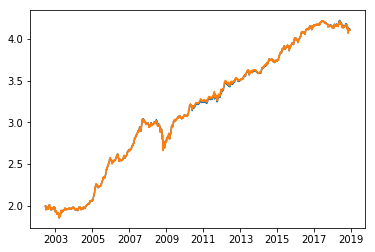

In [10]:
plt.plot(레포트1["날짜"], np.log10(레포트1["누적수익률(%)"] + 100))
plt.plot(레포트2["날짜"], np.log10(레포트2["누적수익률(%)"] + 100))

plt.show()